# Paso 6 - Construcción y Optimización del Modelo

**Problema de negocio:** Los hoteles pierden ingresos por cancelaciones de reservas.
Nuestro sistema hace dos cosas:
1. Predice si una reserva se va a cancelar
2. Predice el precio óptimo por noche según el perfil de la reserva

**ANÁLISIS 1 — Clasificación binaria (cancela / no cancela)**
- Modelos: Regresión Logística, Árbol de Decisión, Naive Bayes

**ANÁLISIS 2 — Regresión (predicción de precio por noche)**
- Modelos: Regresión Lineal, Árbol de Decisión Regressor



## Paso 1 - Importar librerías

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib                     # para guardar los modelos entrenados
import warnings
warnings.filterwarnings('ignore')

# Modelos de clasificación (para predecir cancelación)
from sklearn.linear_model import LogisticRegression      # modelo lineal para clasificación binaria
from sklearn.tree import DecisionTreeClassifier          # árbol de decisión para clasificación
from sklearn.naive_bayes import GaussianNB               # modelo probabilístico

# Modelos de regresión (para predecir precio)
from sklearn.linear_model import LinearRegression        # regresión lineal para predecir números
from sklearn.tree import DecisionTreeRegressor           # árbol de decisión para predecir números

# Métricas de clasificación
from sklearn.metrics import accuracy_score               # % de aciertos totales
from sklearn.metrics import precision_score              # de las que predijo canceladas, cuántas lo eran
from sklearn.metrics import recall_score                 # de las que se cancelaron, cuántas detectó
from sklearn.metrics import f1_score                     # equilibrio entre precision y recall
from sklearn.metrics import roc_auc_score                # capacidad de distinguir entre clases
from sklearn.metrics import classification_report        # resumen completo
from sklearn.metrics import ConfusionMatrixDisplay       # para dibujar la matriz de confusión
from sklearn.metrics import RocCurveDisplay              # para dibujar la curva ROC

# Métricas de regresión
from sklearn.metrics import mean_absolute_error          # error medio absoluto (MAE)
from sklearn.metrics import mean_squared_error           # error cuadrático medio (RMSE)
from sklearn.metrics import r2_score                     # coeficiente de determinación (R²)

# Herramientas de optimización y validación
from sklearn.model_selection import GridSearchCV         # optimización de hiperparámetros
from sklearn.model_selection import cross_val_score      # validación cruzada
from sklearn.model_selection import train_test_split     # dividir datos
from sklearn.preprocessing import StandardScaler         # escalado de datos
from sklearn.preprocessing import OneHotEncoder          # encoding de categóricas

print('Librerías importadas correctamente')

Librerías importadas correctamente


---
# ANÁLISIS 1 — Predicción de Cancelación
## Paso 2 - Cargar datos del EDA

In [31]:
# Cargamos los archivos generados en el Paso 5 (EDA)
X_train = pd.read_csv('X_train.csv')            # variables de entrenamiento
X_test  = pd.read_csv('X_test.csv')             # variables de test
y_train = pd.read_csv('y_train.csv').squeeze()  # cancelaciones de entrenamiento (0/1)
y_test  = pd.read_csv('y_test.csv').squeeze()   # cancelaciones de test (0/1)

# Cargamos la lista de features guardada en el EDA
with open('features.json') as f:
    FEATURES = json.load(f)

print('Datos cargados correctamente')
print('Datos para entrenar:', X_train.shape)
print('Datos para el test: ', X_test.shape)
print('Número de features: ', len(FEATURES))

Datos cargados correctamente
Datos para entrenar: (69781, 245)
Datos para el test:  (17446, 245)
Número de features:  245


## Paso 3 - Escalado de datos

La Regresión Logística necesita que todas las variables estén en la misma escala.
El **StandardScaler** convierte cada variable para que tenga media 0 y desviación 1.
Sin esto, variables con valores grandes dominarían sobre las pequeñas.

In [32]:
# Creamos el escalador
scaler = StandardScaler()

# fit_transform: aprende la escala del train y lo transforma
X_train_scaled = scaler.fit_transform(X_train)

# transform: aplica la misma escala al test sin re-aprender
# importante: el test nunca debe influir en el aprendizaje
X_test_scaled = scaler.transform(X_test)

print('Escalado aplicado correctamente')

Escalado aplicado correctamente


## Paso 4 - Entrenar los 3 modelos de clasificación

Probamos 3 modelos con enfoques muy distintos:
- **Regresión Logística**: modelo lineal, diseñado para clasificación binaria (cancela/no cancela)
- **Árbol de Decisión**: toma decisiones con reglas tipo 'si lead_time > 100 y sin depósito → cancela'
- **Naive Bayes**: modelo probabilístico, muy rápido, calcula la probabilidad de cada clase por separado

In [33]:
# Modelo 1: Regresión Logística
# max_iter=1000: máximo de iteraciones para que converja
# n_jobs=-1: usa todos los núcleos del procesador
print('Entrenando Regresión Logística...')
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train)
print('✅ Regresión Logística entrenada')

Entrenando Regresión Logística...
✅ Regresión Logística entrenada


In [34]:
# Modelo 2: Árbol de Decisión
# max_depth=5: limitamos la profundidad para que no memorice los datos
# min_samples_split=20: necesita al menos 20 muestras para crear una nueva rama
# min_samples_leaf=10: cada hoja debe tener al menos 10 muestras
print('Entrenando Árbol de Decisión...')
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train_scaled, y_train)
print('✅ Árbol de Decisión entrenado')

Entrenando Árbol de Decisión...
✅ Árbol de Decisión entrenado


In [35]:
# Modelo 3: Naive Bayes
# No tiene hiperparámetros complejos, es muy sencillo de entrenar
# Funciona calculando la probabilidad de cancelación para cada variable por separado
print('Entrenando Naive Bayes...')
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
print('✅ Naive Bayes entrenado')

Entrenando Naive Bayes...
✅ Naive Bayes entrenado


## Paso 5 - Tabla comparativa de los 3 modelos

Evaluamos cada modelo con las mismas métricas:
- **Accuracy**: % total de predicciones correctas
- **Precision**: de las que predijo canceladas, cuántas realmente lo eran
- **Recall**: de las que se cancelaron, cuántas detectó el modelo
- **F1-Score**: equilibrio entre Precision y Recall
- **ROC-AUC**: capacidad de distinguir canceladas de no canceladas (0.5=azar, 1.0=perfecto)

In [36]:
# Recorremos los 3 modelos y calculamos sus métricas
modelos_clf = {
    'Regresión Logística': lr,
    'Árbol de Decisión':   dt,
    'Naive Bayes':         nb
}

resultados_clf = []

for nombre, modelo in modelos_clf.items():
    # Predicciones sobre el test
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

    resultados_clf.append({
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4)
    })

# Mostramos la tabla comparativa
df_clf = pd.DataFrame(resultados_clf).set_index('Modelo')
print('=== COMPARATIVA DE MODELOS DE CLASIFICACIÓN ===')
df_clf

=== COMPARATIVA DE MODELOS DE CLASIFICACIÓN ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regresión Logística,0.7980,0.6868,0.4892,0.5714,0.8490
Árbol de Decisión,0.7949,0.6620,0.5204,0.5827,0.8359
Naive Bayes,0.3754,0.3051,0.9935,0.4669,0.5679


## Paso 6 - Gráfico comparativo

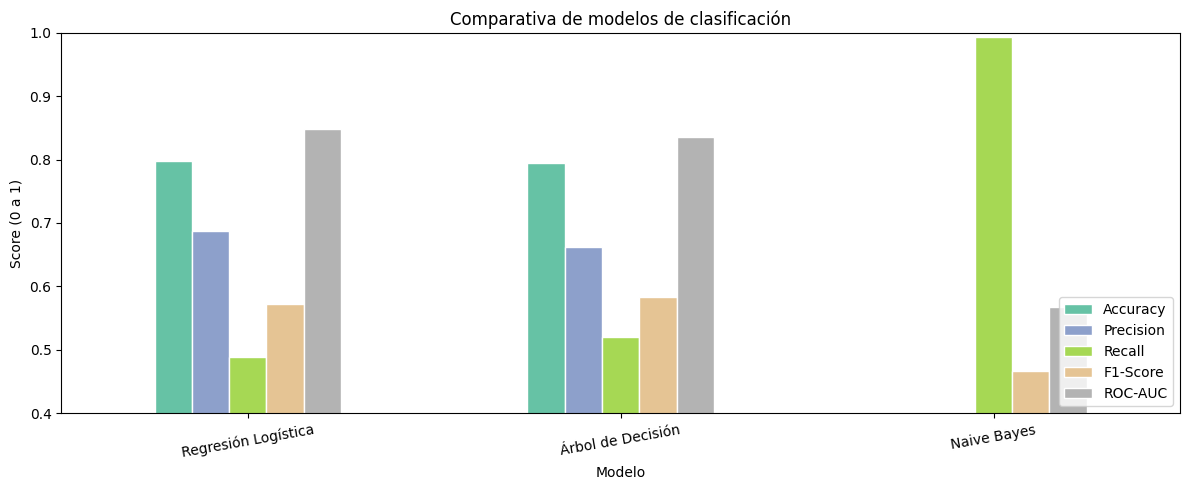

In [37]:
# Gráfico de barras agrupadas con todas las métricas
df_clf.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white')
plt.title('Comparativa de modelos de clasificación')
plt.ylabel('Score (0 a 1)')
plt.ylim(0.4, 1.0)
plt.xticks(rotation=10)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('comparativa_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

## Paso 7 - Modelo ganador y justificación

In [38]:
# Identificamos el modelo ganador por ROC-AUC
ganador_clf = df_clf['ROC-AUC'].idxmax()
auc_ganador = df_clf.loc[ganador_clf, 'ROC-AUC']

print('=======================================')
print('   MODELO GANADOR — CLASIFICACIÓN')
print('=======================================')
print(f'\n🏆 {ganador_clf}')
print(f'   ROC-AUC: {auc_ganador}')
print()
print('¿Por qué este modelo?')
print('  Tiene el mejor ROC-AUC — mide la capacidad')
print('  de distinguir reservas canceladas de no canceladas')
print('  Un ROC-AUC cercano a 1.0 significa que el modelo')
print('  casi nunca se equivoca al clasificar')
print()
print('Ahora optimizamos sus hiperparámetros con GridSearchCV')

   MODELO GANADOR — CLASIFICACIÓN

🏆 Regresión Logística
   ROC-AUC: 0.849

¿Por qué este modelo?
  Tiene el mejor ROC-AUC — mide la capacidad
  de distinguir reservas canceladas de no canceladas
  Un ROC-AUC cercano a 1.0 significa que el modelo
  casi nunca se equivoca al clasificar

Ahora optimizamos sus hiperparámetros con GridSearchCV


## Paso 8 - Optimización con GridSearchCV

Los **hiperparámetros** son los ajustes del modelo que controlamos nosotros.
**GridSearchCV** prueba todas las combinaciones posibles y nos dice cuál es la mejor.
Para cada combinación hace **validación cruzada de 3 folds**.

In [39]:
# Optimización para Regresión Logística
# C: controla la regularización
# C pequeño (0.01) → modelo más simple y conservador
# C grande (100)   → modelo más complejo y ajustado
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    param_grid_lr,
    cv=3,               # validación cruzada de 3 folds
    scoring='roc_auc',  # optimizamos por ROC-AUC
    n_jobs=-1
)

print('Optimizando Regresión Logística...')
grid_lr.fit(X_train_scaled, y_train)
print(f'✅ Mejor C: {grid_lr.best_params_["C"]}')
print(f'   Mejor ROC-AUC en validación: {grid_lr.best_score_:.4f}')

Optimizando Regresión Logística...
✅ Mejor C: 100
   Mejor ROC-AUC en validación: 0.8406


In [40]:
# Optimización para Árbol de Decisión
# max_depth:         profundidad máxima del árbol
# min_samples_split: mínimo de muestras para dividir un nodo
# min_samples_leaf:  mínimo de muestras en una hoja final
param_grid_dt = {
    'max_depth':         [3, 5, 7, 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf':  [5, 10, 20]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

print('Optimizando Árbol de Decisión...')
grid_dt.fit(X_train_scaled, y_train)
print(f'✅ Mejores parámetros: {grid_dt.best_params_}')
print(f'   Mejor ROC-AUC en validación: {grid_dt.best_score_:.4f}')

Optimizando Árbol de Decisión...
✅ Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 50}
   Mejor ROC-AUC en validación: 0.8781


## Paso 9 - Evaluación final del modelo ganador

In [41]:
# Evaluamos los modelos optimizados
modelos_opt = {
    'Regresión Logística (opt)': grid_lr.best_estimator_,
    'Árbol de Decisión (opt)':   grid_dt.best_estimator_,
    'Naive Bayes':               nb
}

resultados_opt = []

for nombre, modelo in modelos_opt.items():
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    resultados_opt.append({
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4)
    })

df_opt = pd.DataFrame(resultados_opt).set_index('Modelo')
print('=== MODELOS OPTIMIZADOS ===')
df_opt

=== MODELOS OPTIMIZADOS ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regresión Logística (opt),0.7980,0.6870,0.4890,0.5713,0.8492
Árbol de Decisión (opt),0.8270,0.7062,0.6362,0.6694,0.8884
Naive Bayes,0.3754,0.3051,0.9935,0.4669,0.5679


In [42]:
# Seleccionamos el modelo final ganador
ganador_final = df_opt['ROC-AUC'].idxmax()
best_model_clf = modelos_opt[ganador_final]

# Predicciones finales
y_pred_final = best_model_clf.predict(X_test_scaled)
y_prob_final = best_model_clf.predict_proba(X_test_scaled)[:, 1]

print(f'🏆 Modelo final: {ganador_final}')
print()
print('=== MÉTRICAS FINALES ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_final):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_final):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_final):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_final):.4f}')
print()
print(classification_report(y_test, y_pred_final, target_names=['No cancelada', 'Cancelada']))

🏆 Modelo final: Árbol de Decisión (opt)

=== MÉTRICAS FINALES ===
Accuracy:  0.8270
Precision: 0.7062
Recall:    0.6362
F1-Score:  0.6694
ROC-AUC:   0.8884

              precision    recall  f1-score   support

No cancelada       0.87      0.90      0.88     12644
   Cancelada       0.71      0.64      0.67      4802

    accuracy                           0.83     17446
   macro avg       0.79      0.77      0.78     17446
weighted avg       0.82      0.83      0.82     17446



## Paso 10 - Matriz de confusión y curva ROC

**Matriz de confusión** — los 4 tipos de predicción posibles:
- **Verdadero Negativo**: predijo no cancelada y era correcta ✅
- **Falso Positivo**: predijo cancelada pero no lo era ❌
- **Falso Negativo**: predijo no cancelada pero sí se canceló ❌
- **Verdadero Positivo**: predijo cancelada y era correcta ✅

**Curva ROC** — cuanto más arriba y a la izquierda, mejor el modelo

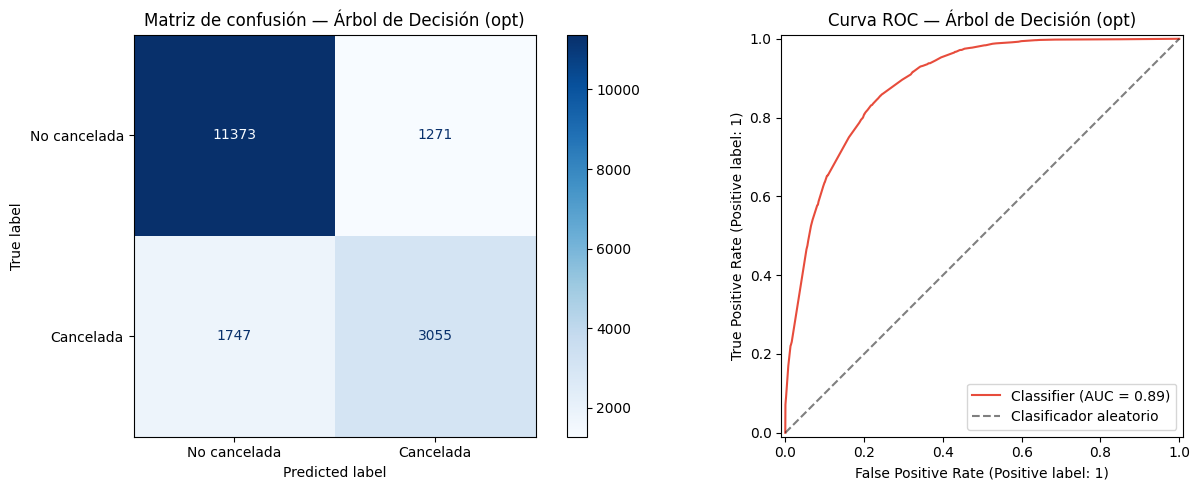

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['No cancelada', 'Cancelada'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Matriz de confusión — {ganador_final}')

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test, y_prob_final,
    ax=axes[1], color='#e74c3c'
)
axes[1].plot([0,1], [0,1], 'k--', alpha=0.5, label='Clasificador aleatorio')
axes[1].set_title(f'Curva ROC — {ganador_final}')
axes[1].legend()

plt.tight_layout()
plt.savefig('matriz_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## Paso 11 - Variables más importantes

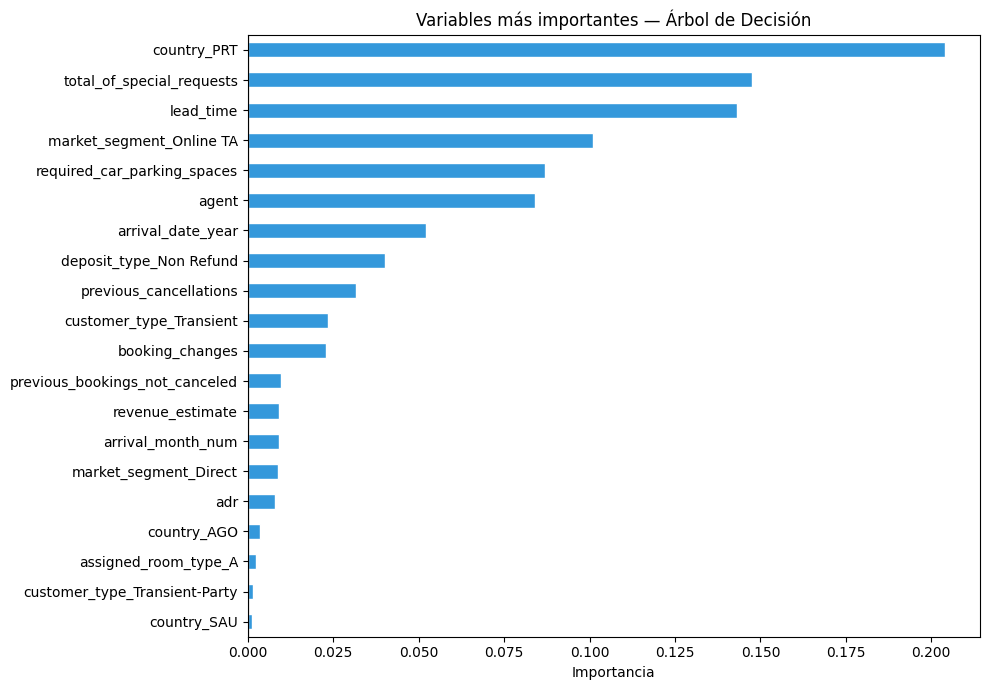

In [44]:
# Extraemos la importancia según el tipo de modelo ganador
if hasattr(best_model_clf, 'coef_'):
    # Regresión Logística: usamos los coeficientes
    # Positivo → aumenta probabilidad de cancelación
    # Negativo → reduce probabilidad de cancelación
    importancias = pd.Series(best_model_clf.coef_[0], index=FEATURES)
    titulo = 'Coeficientes (rojo=cancela más, verde=cancela menos)'
    top20 = importancias.abs().nlargest(20).index
    valores = importancias[top20].sort_values()
    colores = ['#e74c3c' if v > 0 else '#2ecc71' for v in valores]

elif hasattr(best_model_clf, 'feature_importances_'):
    # Árbol de Decisión: usamos la importancia de cada variable
    importancias = pd.Series(best_model_clf.feature_importances_, index=FEATURES)
    titulo = 'Variables más importantes — Árbol de Decisión'
    valores = importancias.nlargest(20).sort_values()
    colores = '#3498db'

plt.figure(figsize=(10, 7))
valores.plot(kind='barh', color=colores, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title(titulo)
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('variables_importantes.png', dpi=150, bbox_inches='tight')
plt.show()

## Paso 12 - Validación cruzada

Divide el train en 5 partes. En cada ronda entrena con 4 y evalúa con 1.
Si los 5 resultados son parecidos, el modelo es estable y no hace **overfitting**.

**Overfitting** = el modelo memoriza el train pero falla con datos nuevos

In [45]:
# Validación cruzada de 5 folds
cv_scores = cross_val_score(
    best_model_clf,
    X_train_scaled, y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print('Validación cruzada — 5 folds (ROC-AUC):')
for i, score in enumerate(cv_scores, 1):
    print(f'   Fold {i}: {score:.4f}')

print(f'\n   Media:        {cv_scores.mean():.4f}')
print(f'   Desv. std:    {cv_scores.std():.4f}  (cuanto menor, más estable)')
print(f'   ROC-AUC test: {roc_auc_score(y_test, y_prob_final):.4f}')
print()
print('→ Si media ≈ ROC-AUC test, el modelo generaliza bien (no hay overfitting)')

Validación cruzada — 5 folds (ROC-AUC):
   Fold 1: 0.8762
   Fold 2: 0.8842
   Fold 3: 0.8799
   Fold 4: 0.8811
   Fold 5: 0.8784

   Media:        0.8800
   Desv. std:    0.0027  (cuanto menor, más estable)
   ROC-AUC test: 0.8884

→ Si media ≈ ROC-AUC test, el modelo generaliza bien (no hay overfitting)


## Paso 13 - Guardar modelo de cancelación

In [46]:
# Guardamos el modelo entrenado
joblib.dump(best_model_clf, 'modelo_cancelacion.pkl')

# Guardamos el escalador (los datos nuevos también hay que escalarlos)
joblib.dump(scaler, 'scaler.pkl')

print('Archivos guardados:')
print('  modelo_cancelacion.pkl → modelo de predicción de cancelación')
print('  scaler.pkl             → escalador de datos')

Archivos guardados:
  modelo_cancelacion.pkl → modelo de predicción de cancelación
  scaler.pkl             → escalador de datos


---
# ANÁLISIS 2 — Predicción de Precio por Noche (ADR)

Construimos un segundo modelo que predice el **precio óptimo por noche**
según el perfil de la reserva.

Este es un problema de **regresión** (predecir un número continuo)
a diferencia del anterior que era **clasificación** (predecir 0 o 1).

**Métricas de regresión:**
- **MAE**: error medio en euros — cuánto se equivoca de media
- **RMSE**: penaliza más los errores grandes
- **R²**: qué % de la variación del precio explica el modelo

## Paso 14 - Preparar datos para predicción de precio

In [47]:
# Cargamos el CSV original porque necesitamos adr como variable objetivo
df_precio = pd.read_csv('hotel_bookings.csv')
print('Dataset original cargado:', df_precio.shape)

Dataset original cargado: (119390, 32)


In [48]:
# Limpieza mínima del dataset para predicción de precio
cols_eliminar = ['reservation_status', 'reservation_status_date',
                 'arrival_date_week_number', 'arrival_date_day_of_month', 'company']
df_precio = df_precio.drop(columns=cols_eliminar)

# Tratamos nulos
df_precio['children'] = df_precio['children'].fillna(0)
df_precio['country']  = df_precio['country'].fillna('Unknown')
df_precio['agent']    = df_precio['agent'].fillna(0)

# Eliminamos filas sin huéspedes
df_precio = df_precio[~((df_precio['adults']==0) & (df_precio['children']==0) & (df_precio['babies']==0))]

# Eliminamos precios negativos o absurdos
df_precio = df_precio[(df_precio['adr'] > 0) & (df_precio['adr'] < 5000)]

# Mes como número
mes_num = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
           'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
df_precio['arrival_month_num'] = df_precio['arrival_date_month'].map(mes_num)
df_precio = df_precio.drop(columns=['arrival_date_month'])

print('Dataset limpio:', df_precio.shape)

Dataset limpio: (117398, 27)


In [49]:
# OneHotEncoder en variables categóricas
cat_cols_precio = df_precio.select_dtypes(include='object').columns.tolist()

encoder_precio = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_precio = encoder_precio.fit_transform(df_precio[cat_cols_precio])

encoded_df_precio = pd.DataFrame(
    encoded_precio,
    columns=encoder_precio.get_feature_names_out(cat_cols_precio),
    index=df_precio.index
)

df_precio = pd.concat([df_precio, encoded_df_precio], axis=1)
df_precio = df_precio.drop(columns=cat_cols_precio)

print('Dataset con encoding:', df_precio.shape)

Dataset con encoding: (117398, 243)


In [50]:
# Definimos X e Y para la predicción de precio
# Y = adr (precio por noche) — lo que queremos predecir
# X = todo lo demás excepto adr e is_canceled
X_precio = df_precio.drop(columns=['adr', 'is_canceled'])
y_precio = df_precio['adr']

# Dividimos en train y test
X_precio_train, X_precio_test, y_precio_train, y_precio_test = train_test_split(
    X_precio, y_precio, test_size=0.2, random_state=42
)

# Escalamos los datos
scaler_precio = StandardScaler()
X_precio_train_scaled = scaler_precio.fit_transform(X_precio_train)
X_precio_test_scaled  = scaler_precio.transform(X_precio_test)

print('Datos para entrenar:', X_precio_train.shape)
print('Datos para el test: ', X_precio_test.shape)
print(f'Precio medio del dataset: €{y_precio.mean():.2f}/noche')

Datos para entrenar: (93918, 241)
Datos para el test:  (23480, 241)
Precio medio del dataset: €103.50/noche


## Paso 15 - Entrenar los 2 modelos de regresión

Comparamos dos modelos con enfoques distintos:
- **Regresión Lineal**: predice el precio con una ecuación matemática
- **Árbol de Decisión Regressor**: predice el precio con reglas tipo 'si hotel=City y mes=Agosto → precio alto'

In [51]:
# Modelo 1: Regresión Lineal
print('Entrenando Regresión Lineal...')
lr_precio = LinearRegression()
lr_precio.fit(X_precio_train_scaled, y_precio_train)
print('✅ Regresión Lineal entrenada')

Entrenando Regresión Lineal...
✅ Regresión Lineal entrenada


In [52]:
# Modelo 2: Árbol de Decisión Regressor
# max_depth=8: limitamos la profundidad para evitar overfitting
# min_samples_split=20: necesita al menos 20 muestras para dividir
# min_samples_leaf=10: cada hoja debe tener al menos 10 muestras
print('Entrenando Árbol de Decisión Regressor...')
dt_precio = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt_precio.fit(X_precio_train_scaled, y_precio_train)
print('✅ Árbol de Decisión Regressor entrenado')

Entrenando Árbol de Decisión Regressor...
✅ Árbol de Decisión Regressor entrenado


## Paso 16 - Tabla comparativa de los 2 modelos de precio

In [53]:
# Evaluamos los 2 modelos con las métricas de regresión
modelos_reg = {
    'Regresión Lineal':            lr_precio,
    'Árbol de Decisión Regressor': dt_precio
}

resultados_reg = []

for nombre, modelo in modelos_reg.items():
    # Predicciones sobre el test
    y_pred_reg = modelo.predict(X_precio_test_scaled)

    mae  = mean_absolute_error(y_precio_test, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_precio_test, y_pred_reg))
    r2   = r2_score(y_precio_test, y_pred_reg)

    resultados_reg.append({
        'Modelo': nombre,
        'MAE (€)':  round(mae, 2),
        'RMSE (€)': round(rmse, 2),
        'R²':       round(r2, 4)
    })

df_reg = pd.DataFrame(resultados_reg).set_index('Modelo')
print('=== COMPARATIVA DE MODELOS DE REGRESIÓN ===')
df_reg

=== COMPARATIVA DE MODELOS DE REGRESIÓN ===


,MAE (€),RMSE (€),R²
Modelo,,,
Regresión Lineal,24.20,33.42,0.4839
Árbol de Decisión Regressor,18.78,27.17,0.6591


## Paso 17 - Gráfico comparativo de precio

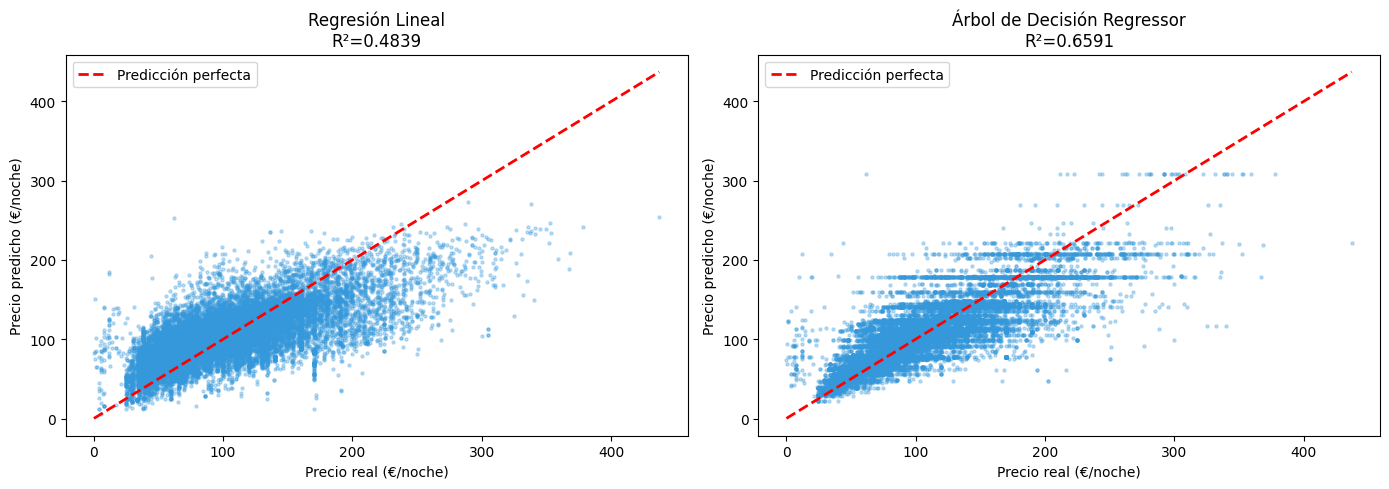

In [54]:
# Gráfico precio real vs precio predicho para cada modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (nombre, modelo) in enumerate(modelos_reg.items()):
    y_pred_reg = modelo.predict(X_precio_test_scaled)

    axes[i].scatter(y_precio_test, y_pred_reg, alpha=0.3, color='#3498db', s=5)
    # Línea perfecta: si el modelo fuera perfecto todos los puntos estarían aquí
    axes[i].plot([y_precio_test.min(), y_precio_test.max()],
                 [y_precio_test.min(), y_precio_test.max()],
                 'r--', linewidth=2, label='Predicción perfecta')
    r2 = r2_score(y_precio_test, y_pred_reg)
    axes[i].set_title(f'{nombre}\nR²={r2:.4f}')
    axes[i].set_xlabel('Precio real (€/noche)')
    axes[i].set_ylabel('Precio predicho (€/noche)')
    axes[i].legend()

plt.tight_layout()
plt.savefig('comparativa_precio.png', dpi=150, bbox_inches='tight')
plt.show()

## Paso 18 - Modelo ganador de precio y guardado

In [55]:
# El modelo ganador es el que tiene mayor R²
ganador_precio = df_reg['R²'].idxmax()
best_model_precio = modelos_reg[ganador_precio]

y_pred_precio_final = best_model_precio.predict(X_precio_test_scaled)
mae_final  = mean_absolute_error(y_precio_test, y_pred_precio_final)
rmse_final = np.sqrt(mean_squared_error(y_precio_test, y_pred_precio_final))
r2_final   = r2_score(y_precio_test, y_pred_precio_final)

print(f'🏆 Modelo ganador de precio: {ganador_precio}')
print()
print('=== MÉTRICAS FINALES ===')
print(f'MAE:  €{mae_final:.2f}  → el modelo se equivoca de media €{mae_final:.2f} por noche')
print(f'RMSE: €{rmse_final:.2f}  → penalizando los errores grandes')
print(f'R²:   {r2_final:.4f}  → el modelo explica el {r2_final*100:.1f}% de la variación del precio')

# Guardamos el modelo ganador y su escalador
joblib.dump(best_model_precio, 'modelo_precio.pkl')
joblib.dump(scaler_precio,     'scaler_precio.pkl')

print()
print('Archivos guardados:')
print('  modelo_precio.pkl  → modelo de predicción de precio')
print('  scaler_precio.pkl  → escalador para el modelo de precio')

🏆 Modelo ganador de precio: Árbol de Decisión Regressor

=== MÉTRICAS FINALES ===
MAE:  €18.78  → el modelo se equivoca de media €18.78 por noche
RMSE: €27.17  → penalizando los errores grandes
R²:   0.6591  → el modelo explica el 65.9% de la variación del precio

Archivos guardados:
  modelo_precio.pkl  → modelo de predicción de precio
  scaler_precio.pkl  → escalador para el modelo de precio


## Paso 19 - Resumen final para la presentación

In [56]:
print('================================================')
print('          RESUMEN FINAL DEL PROYECTO')
print('================================================')
print()
print('PROBLEMA DE NEGOCIO:')
print('  Los hoteles pierden ingresos por cancelaciones.')
print('  Nuestro sistema predice cancelaciones y optimiza')
print('  el precio por noche según el perfil del cliente.')
print()
print('DATASET:')
print(f'  {X_train.shape[0] + X_test.shape[0]:,} reservas totales')
print(f'  {len(FEATURES)} variables predictoras')
print(f'  Tasa de cancelación global: ~37%')
print()
print('─' * 48)
print('ANÁLISIS 1 — Predicción de cancelación')
print('─' * 48)
print('  Tipo:    Clasificación binaria (cancela/no cancela)')
print('  Modelos: Regresión Logística, Árbol de Decisión, Naive Bayes')
print('  Optim.:  GridSearchCV con validación cruzada 3 folds')
print(f'  Ganador: {ganador_final}')
print(f'  ROC-AUC: {roc_auc_score(y_test, y_prob_final):.4f}')
print(f'  Accuracy:{accuracy_score(y_test, y_pred_final):.4f}')
print()
print('─' * 48)
print('ANÁLISIS 2 — Predicción de precio por noche')
print('─' * 48)
print('  Tipo:    Regresión (predice un número continuo)')
print('  Modelos: Regresión Lineal, Árbol de Decisión Regressor')
print(f'  Ganador: {ganador_precio}')
print(f'  MAE:     €{mae_final:.2f} de error medio por noche')
print(f'  R²:      {r2_final:.4f} — explica el {r2_final*100:.1f}% de la variación del precio')
print()
print('─' * 48)
print('PATRONES CLAVE ENCONTRADOS:')
print('─' * 48)
print('  ✅ El 37% de las reservas se cancelan')
print('  ✅ Más antelación = más probabilidad de cancelar')
print('  ✅ City Hotel cancela más que Resort Hotel')
print('  ✅ Sin depósito = mayor tasa de cancelación')
print('  ✅ Agencias online generan más cancelaciones')
print('  ✅ Quien canceló antes, tiene más riesgo de volver a cancelar')
print()
print('─' * 48)
print('MEJORAS FUTURAS:')
print('─' * 48)
print('  → Clasificar clientes por nivel de riesgo de cancelación')
print('  → Aplicar tarifas personalizadas según el riesgo')
print('  → Añadir datos externos (eventos, clima, competencia)')
print('  → Reentrenar el modelo mensualmente con datos nuevos')
print('================================================')

          RESUMEN FINAL DEL PROYECTO

PROBLEMA DE NEGOCIO:
  Los hoteles pierden ingresos por cancelaciones.
  Nuestro sistema predice cancelaciones y optimiza
  el precio por noche según el perfil del cliente.

DATASET:
  87,227 reservas totales
  245 variables predictoras
  Tasa de cancelación global: ~37%

────────────────────────────────────────────────
ANÁLISIS 1 — Predicción de cancelación
────────────────────────────────────────────────
  Tipo:    Clasificación binaria (cancela/no cancela)
  Modelos: Regresión Logística, Árbol de Decisión, Naive Bayes
  Optim.:  GridSearchCV con validación cruzada 3 folds
  Ganador: Árbol de Decisión (opt)
  ROC-AUC: 0.8884
  Accuracy:0.8270

────────────────────────────────────────────────
ANÁLISIS 2 — Predicción de precio por noche
────────────────────────────────────────────────
  Tipo:    Regresión (predice un número continuo)
  Modelos: Regresión Lineal, Árbol de Decisión Regressor
  Ganador: Árbol de Decisión Regressor
  MAE:     €18.78 de